# Computing I Assignment 3
Kwatcho Mahinanda
10/1/2025

### Question 1: How many works have “artificial intelligence” in the title?

To answer this, I used the OpenAlex Works API with the filter `title.search=artificial intelligence`.  
I relied on the `meta.count` field in the JSON response, which directly reports the total number of matching works.  
This provides a  way to get the overall count without needing to loop through or group results.  
My output is a single number representing the total works with “artificial intelligence” in the title.


In [2]:
import requests
import pandas as pd

# Base URL for OpenAlex Works
BASE_URL = "https://api.openalex.org/works"

parameters = {
    "filter": "title.search:artificial intelligence"
}

response = requests.get(BASE_URL, params=parameters)
data = response.json()

total_meta_count = data["meta"]["count"]
print(f"Total works (from meta.count) with 'artificial intelligence' in the title: {total_meta_count}")


Total works (from meta.count) with 'artificial intelligence' in the title: 198681


### Question 2: Publications since 2020 grouped by country

To answer this, I filtered the OpenAlex Works API to include only works published from 2020 onward with “artificial intelligence” in the title.  
I then grouped the results by the country code of the authors’ affiliated institutions.  
This gave me a table of countries and their publication counts, which I sorted in descending order.  
The country codes follow the standard ISO two-letter format (e.g., US = United States, CN = China).


In [3]:
BASE_URL = "https://api.openalex.org/works"

# Filters: since 2020 and AI in title
parameters = {
    "filter": "from_publication_date:2020-01-01,title.search:artificial intelligence",
    "group_by": "institutions.country_code"
}

response = requests.get(BASE_URL, params=parameters)
data = response.json()

# Turn the grouped results into a DataFrame
groups = data.get("group_by", [])
df_q2 = pd.DataFrame(groups)

# Sort by publication count, descending
df_q2_sorted = df_q2.sort_values("count", ascending=False).reset_index(drop=True)

# Display table of countries
display(df_q2_sorted)



,key,key_display_name,count
0,https://openalex.org/countries/US,United States of America,20236
1,https://openalex.org/countries/CN,China,15761
2,https://openalex.org/countries/IN,India,11163
3,https://openalex.org/countries/GB,United Kingdom of Great Britain and Northern I...,6817
4,https://openalex.org/countries/IT,Italy,4129
...,...,...,...
188,https://openalex.org/countries/GL,Greenland,1
189,https://openalex.org/countries/GN,Guinea,1
190,https://openalex.org/countries/HT,Haiti,1
191,https://openalex.org/countries/NC,New Caledonia,1


### Question 3: Top 10 most cited AI papers since 2020

To answer this, I filtered the OpenAlex Works API to include works published from 2020 onward with “artificial intelligence” in the title.  
I then sorted the results by citation count in descending order and selected the top 10.  
For each work, I collected the title, publication year, citation count, authors, and their affiliated institutions, and displayed these in a table.


In [5]:
BASE_URL = "https://api.openalex.org/works"

# Since 2020 + AI in title, sorted by citations (desc), top 10
params = {
    "filter": "from_publication_date:2020-01-01,title.search:artificial intelligence",
    "sort": "cited_by_count:desc",
    "per_page": 10,
    "select": ",".join([
        "id",
        "display_name",
        "publication_year",
        "cited_by_count",
        "authorships"  # we'll extract names & institutions directly from this list
    ])
}

r = requests.get(BASE_URL, params=params)
items = r.json().get("results", [])

rows = []
for w in items:
    # authorships is a list of dicts; each has 'author' and 'institutions'
    auths = w.get("authorships", []) or []

    # collect author names (preserve order, drop empties)
    authors = []
    for a in auths:
        name = (a.get("author") or {}).get("display_name")
        if name and name not in authors:
            authors.append(name)

    # collect institution names (flatten across authorships; preserve order)
    insts = []
    for a in auths:
        for inst in (a.get("institutions") or []):
            nm = inst.get("display_name")
            if nm and nm not in insts:
                insts.append(nm)

    rows.append({
        "title": w.get("display_name"),
        "publication_year": w.get("publication_year"),
        "cited_by_count": w.get("cited_by_count"),
        "authors": ", ".join(authors),
        "institutions": ", ".join(insts)
    })

df_top10 = pd.DataFrame(rows).sort_values("cited_by_count", ascending=False).reset_index(drop=True)
display(df_top10)


,title,publication_year,cited_by_count,authors,institutions
0,Artificial Intelligence in Education: A Review,2020,2267,"Lijia Chen, Pingping Chen, Zhijian Lin","Yango University, Fuzhou University"
1,The role of artificial intelligence in achievi...,2020,2195,"Ricardo Vinuesa, Hossein Azizpour, Iolanda Lei...","Swedish e-Science Research Centre, KTH Royal I..."
2,Using Artificial Intelligence to Detect COVID-...,2020,1956,"Lin Li, Lixin Qin, Zeguo Xu, Youbing Yin, Xin ...","Jianghan University, Wuhan Pulmonary Hospital,..."
3,Revolutionizing healthcare: the role of artifi...,2023,1629,"Shuroug A. Alowais, Sahar S. Alghamdi, Nada Al...",King Saud bin Abdulaziz University for Health ...
4,Comparing Physician and Artificial Intelligenc...,2023,1576,"John W. Ayers, Adam Poliak, Mark Dredze, Eric ...","University of California, San Diego, Qualcomm ..."
5,A Survey on Explainable Artificial Intelligenc...,2020,1560,"Erico Tjoa, Cuntai Guan","Alibaba Group (China), Nanyang Technological U..."
6,Human Trust in Artificial Intelligence: Review...,2020,1419,"Ella Glikson, Anita Williams Woolley","Bar-Ilan University, Carnegie Mellon University"
7,Artificial Intelligence (AI) applications for ...,2020,1416,"Raju Vaishya, Mohd Javaid, Ibrahim Haleem Khan...","Indraprastha Apollo Hospitals, Jamia Millia Is..."
8,Photonics for artificial intelligence and neur...,2021,1399,"Bhavin J. Shastri, Alexander N. Tait, Thomas F...","Queen's University, Princeton University, Univ..."
9,Review of Artificial Intelligence Techniques i...,2020,1396,"Feng Shi, Jun Wang, Jun Shi, Ziyan Wu, Qian Wa...","United Imaging Healthcare (China), Shanghai Un..."


### Question 4: Yearly trends in AI-related publications since 2000

I queried the OpenAlex Works API for works with specific keywords in the title from 2000 onward, grouping results by `publication_year`.  
The keywords were “artificial intelligence,” “LLM,” “GPT,” and "Machine Learning".  
For each keyword, I extracted the yearly counts and combined them into a single DataFrame.  
I then plotted the results as a line chart to compare how publication trends for these terms have changed over time.


### "Artificial Intelligence"

In [6]:
BASE_URL = "https://api.openalex.org/works"

# Artificial intelligence yearly counts
params_ai = {
    "filter": "title.search:artificial intelligence,from_publication_date:2000-01-01",
    "group_by": "publication_year",
    "per_page": 200
}

resp_ai = requests.get(BASE_URL, params=params_ai)
data_ai = resp_ai.json()
df_ai = pd.DataFrame(data_ai.get("group_by", []))
df_ai = df_ai[["key", "count"]]  # keep only relevant columns
df_ai.rename(columns={"key": "year", "count": "ai_count"}, inplace=True)
df_ai["year"] = df_ai["year"].astype(int)

#display(df_ai)


### "LLM"

In [7]:
# LLM yearly counts
params_llm = {
    "filter": "title.search:LLM,from_publication_date:2000-01-01",
    "group_by": "publication_year",
    "per_page": 200
}

resp_llm = requests.get(BASE_URL, params=params_llm)
data_llm = resp_llm.json()
df_llm = pd.DataFrame(data_llm.get("group_by", []))
df_llm = df_llm[["key", "count"]]  # keep only relevant columns
df_llm.rename(columns={"key": "year", "count": "llm_count"}, inplace=True)
df_llm["year"] = df_llm["year"].astype(int)

#display(df_llm)


### "GPT"

In [8]:
# GPT yearly counts
params_gpt = {
    "filter": "title.search:GPT,from_publication_date:2000-01-01",
    "group_by": "publication_year",
    "per_page": 200
}

resp_gpt = requests.get(BASE_URL, params=params_gpt)
data_gpt = resp_gpt.json()
df_gpt = pd.DataFrame(data_gpt.get("group_by", []))
df_gpt = df_gpt[["key", "count"]]  # keep only relevant columns
df_gpt.rename(columns={"key": "year", "count": "gpt_count"}, inplace=True)
df_gpt["year"] = df_gpt["year"].astype(int)

#display(df_gpt)


### "Machine Learning"

In [10]:
# Machine learning yearly counts
params_ml = {
    "filter": "title.search:machine learning,from_publication_date:2000-01-01",
    "group_by": "publication_year",
    "per_page": 200
}

resp_ml = requests.get(BASE_URL, params=params_ml)
data_ml = resp_ml.json()
df_ml = pd.DataFrame(data_ml.get("group_by", []))
df_ml = df_ml[["key", "count"]]  # keep only relevant columns
df_ml.rename(columns={"key": "year", "count": "ml_count"}, inplace=True)
df_ml["year"] = df_ml["year"].astype(int)

#display(df_ml)


### Plot

    year  ai_count  llm_count  gpt_count  ml_count
21  2021     16578         25        138     42331
22  2022     19168         49        212     48637
23  2023     29639       1631       1764     62404
24  2024     46092      10204       2492     77829
25  2025     40337       9691       1354     61368


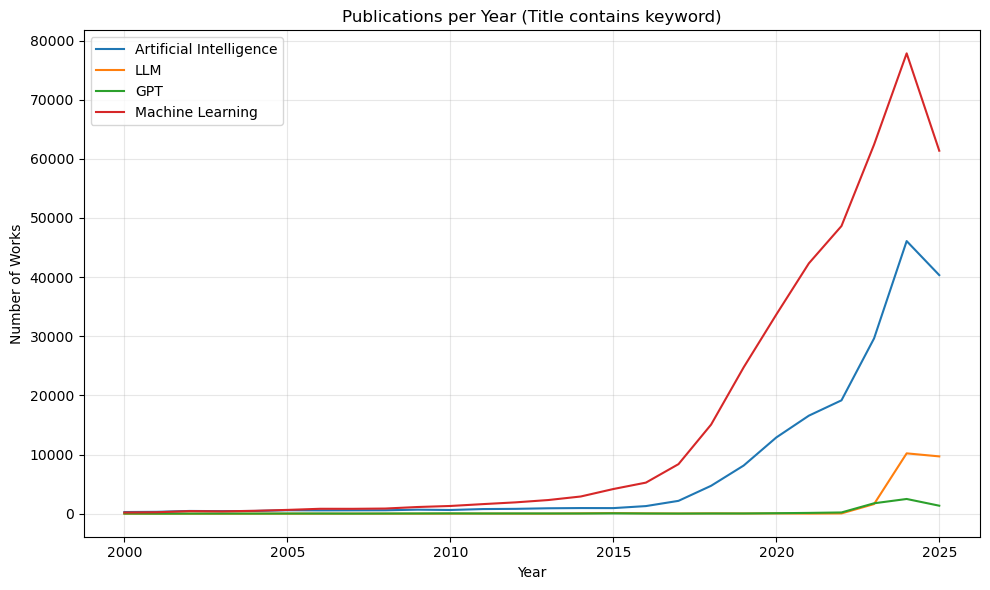

In [11]:
import matplotlib.pyplot as plt

# Merge all dataframes on 'year'
df_trends = (
    df_ai.merge(df_llm, on="year", how="outer")
         .merge(df_gpt, on="year", how="outer")
         .merge(df_ml, on="year", how="outer")
         .fillna(0)
         .sort_values("year")
)

print(df_trends.tail())

# Plot
plt.figure(figsize=(10,6))
plt.plot(df_trends["year"], df_trends["ai_count"], label="Artificial Intelligence")
plt.plot(df_trends["year"], df_trends["llm_count"], label="LLM")
plt.plot(df_trends["year"], df_trends["gpt_count"], label="GPT")
plt.plot(df_trends["year"], df_trends["ml_count"], label="Machine Learning")

plt.title("Publications per Year (Title contains keyword)")
plt.xlabel("Year")
plt.ylabel("Number of Works")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
